# `Telco Customer Churn Prediction`

## `Project Overview`

Customer churn — when customers stop doing business with a company — is a critical business problem. Retaining customers is often more cost-effective than acquiring new ones. In this project, we build a machine learning model to **predict whether a customer will churn** using demographic and service-related data provided by a telecom company.

---

## `Dataset Information`

The dataset is from a fictional telco company and includes the following:
- **Demographic information** (gender, senior citizen, partner, dependents)
- **Account information** (tenure, contract type, payment method)
- **Services signed up** (internet service, online security, device protection, etc.)
- **Target variable**: `Churn` (Yes/No)

---

## `Objective`

Our goal is to:
- **Identify customers at risk of churning**
- Use predictive modeling to support proactive customer retention strategies
- Evaluate and compare models using metrics like **recall, precision, F1-score, and accuracy**

---

## `Steps in the Project`

1. **Exploratory Data Analysis (EDA)**
   - Visualize churn distribution
   - Examine categorical and numerical feature relationships
2. **Data Preprocessing**
   - Handle missing values and data types
   - Encode categorical variables (ordinal vs. nominal)
   - Address class imbalance using SMOTE or SMOTEENN
3. **Model Building**
   - Train baseline models (Logistic Regression, Random Forest, etc.)
   - Tune hyperparameters and evaluate performance
4. **Model Evaluation**
   - Use confusion matrix, classification report, and ROC-AUC
   - Focus on recall (ability to catch churners)
5. **Conclusion & Insights**
   - Feature importance analysis
   - Business recommendations for reducing churn

---

## `Business Impact`

By accurately predicting churn, Telco can:
- Target high-risk customers with retention offers
- Allocate resources more efficiently
- Improve customer satisfaction and loyalty

---


# `Load the dataset`

In [69]:
import pandas as pd
import numpy as np

In [70]:
df = pd.read_csv('data/Telco-Customer-Churn.csv')

In [71]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [72]:
df.shape

(7043, 21)

# `EDA and Data Cleaning`

# `Univariate analysis`

In [73]:
import matplotlib.pyplot as plt
import seaborn as sns

## `Gender Distribution plot`

Text(0.5, 1.0, 'Gender Distribution')

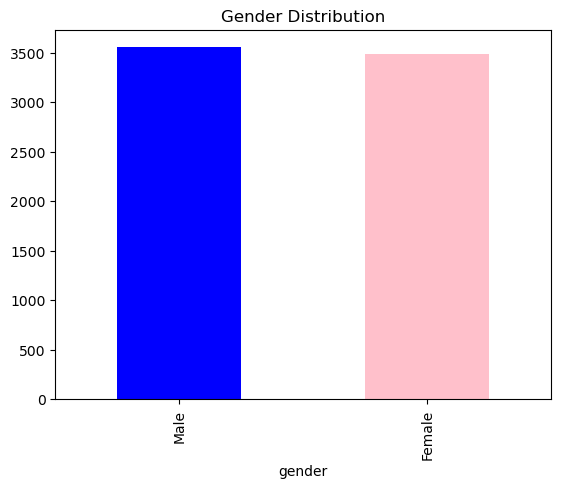

In [74]:
df['gender'].value_counts().plot(kind='bar', color=['blue', 'pink'])
plt.title('Gender Distribution')

## `Senior Citizen Distribution plot`

Text(0.5, 1.0, 'Senior Citizen Distribution')

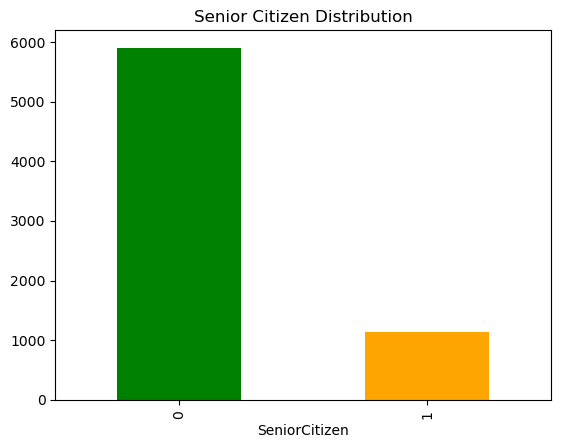

In [75]:
df['SeniorCitizen'] = df['SeniorCitizen'].astype('category')
df['SeniorCitizen'].value_counts().plot(kind='bar', color=['green', 'orange'])
plt.title('Senior Citizen Distribution')

## `Dependents Distribution plot`

Text(0.5, 1.0, 'Dependents Distribution')

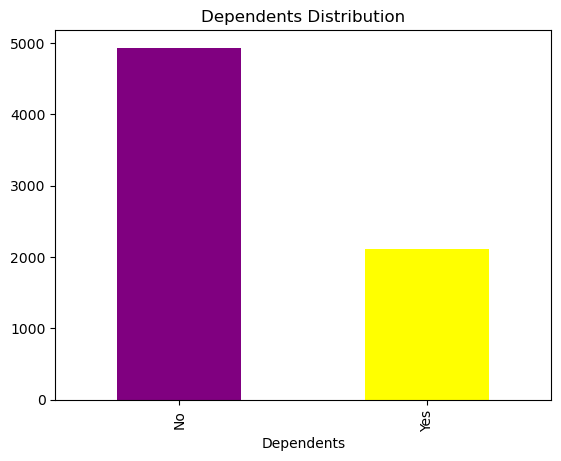

In [76]:
df['Dependents'].value_counts().plot(kind='bar', color=['purple', 'yellow'])
plt.title('Dependents Distribution')

## `Payment Method Distribution plot`

<Axes: xlabel='PaymentMethod'>

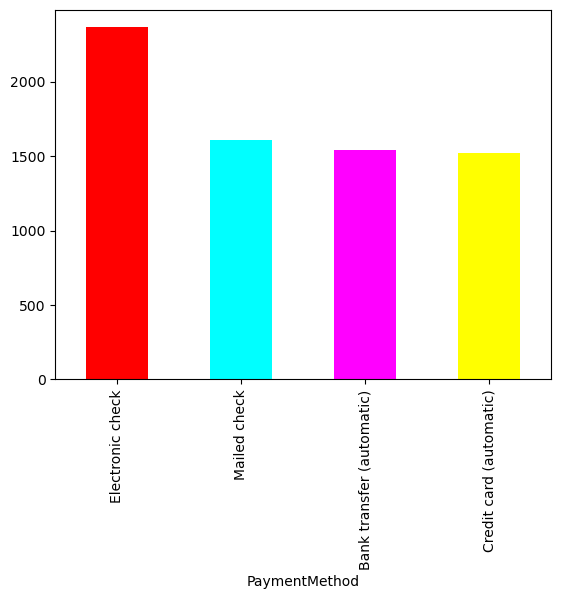

In [77]:
df['PaymentMethod'].value_counts().plot(kind='bar', color=['red', 'cyan', 'magenta', 'yellow'])

## `Check for Null Values`

In [78]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

## `Churn Distribution plot`

Text(0.5, 1.0, 'Churn Distribution')

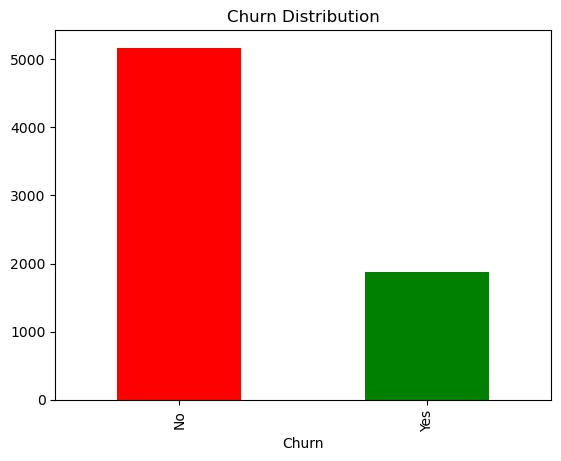

In [79]:
df['Churn'].value_counts().plot(kind='bar', color=['red', 'green'])
plt.title('Churn Distribution')

## `PaperBill Distribution plot`

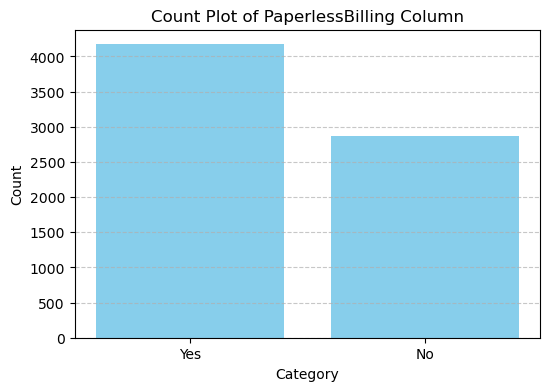

In [80]:
counts = df['PaperlessBilling'].value_counts()

# Plot using Matplotlib
plt.figure(figsize=(6, 4))
plt.bar(counts.index, counts.values, color='skyblue')
plt.xlabel('Category')
plt.ylabel('Count')
plt.title('Count Plot of PaperlessBilling Column')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## `Device Protection Distribution plot`

Text(0.5, 1.0, 'Device Protection Distribution')

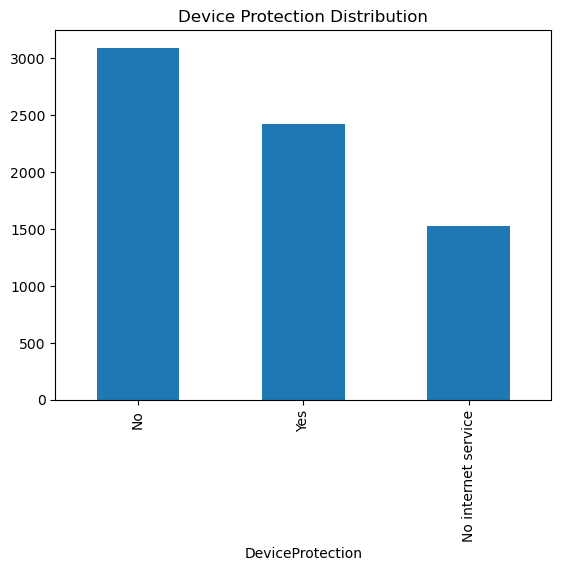

In [81]:
df['DeviceProtection'].value_counts().plot(kind='bar')
plt.title('Device Protection Distribution')

## `Multiple Lines Distribution plot`

<Axes: xlabel='MultipleLines'>

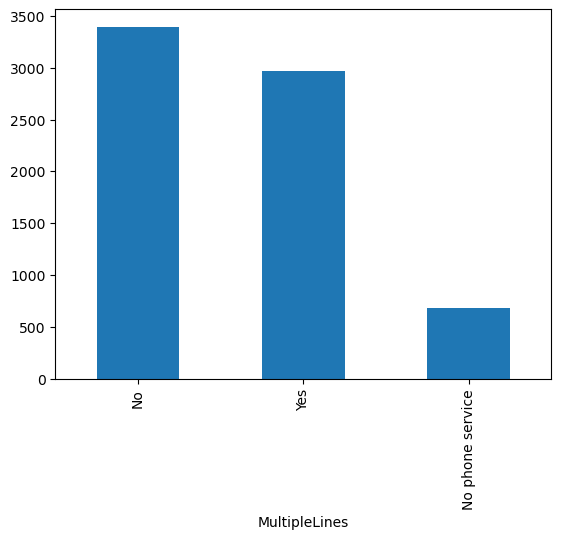

In [82]:
df['MultipleLines'].value_counts().plot(kind='bar')

## `Monthly Charges Histogram`

<Axes: xlabel='MonthlyCharges', ylabel='Density'>

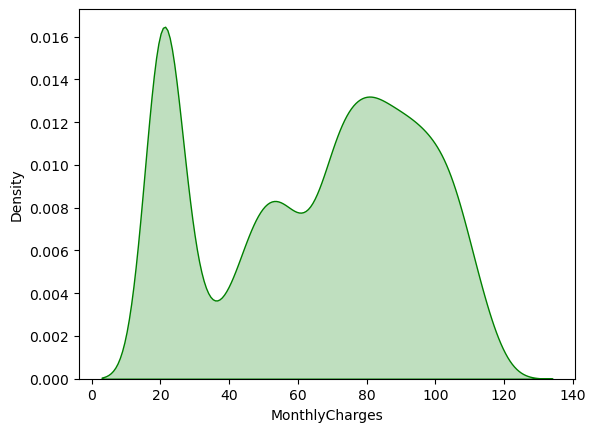

In [83]:
sns.kdeplot(df['MonthlyCharges'], color='green', fill=True)

## `Tenure Histogram`

<Axes: xlabel='tenure', ylabel='Density'>

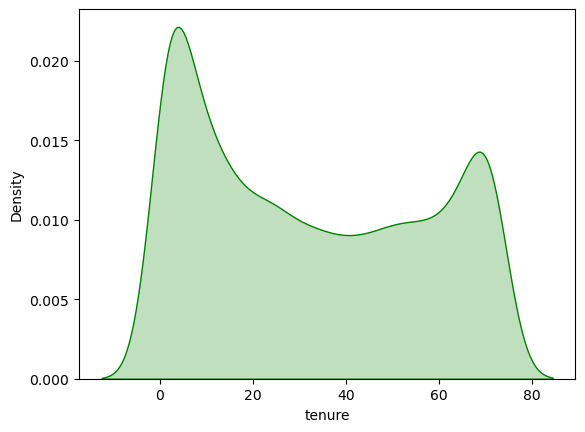

In [84]:
sns.kdeplot(df['tenure'], color='green', fill=True)

## `Streaming TV Distribution plot`

<Axes: xlabel='StreamingTV'>

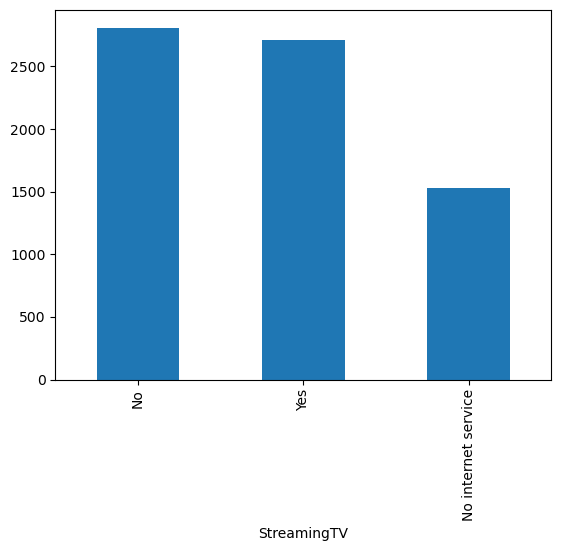

In [85]:
df['StreamingTV'].value_counts().plot(kind='bar')

## `Online Backup Distribution plot`

<Axes: xlabel='OnlineBackup'>

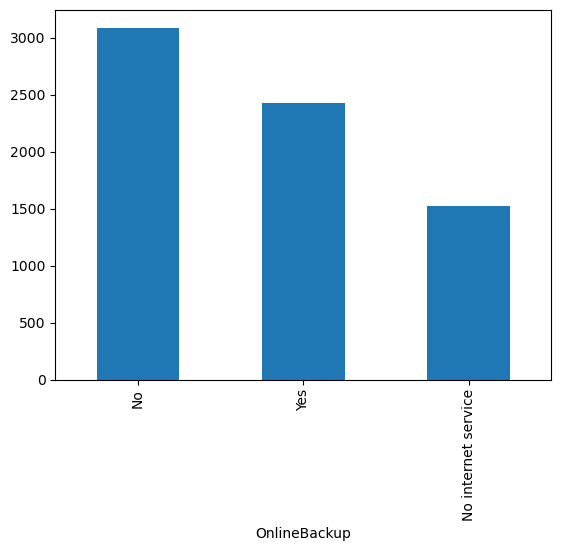

In [86]:
df['OnlineBackup'].value_counts().plot(kind='bar')

## `Tech Support Distribution plot`

<Axes: xlabel='TechSupport'>

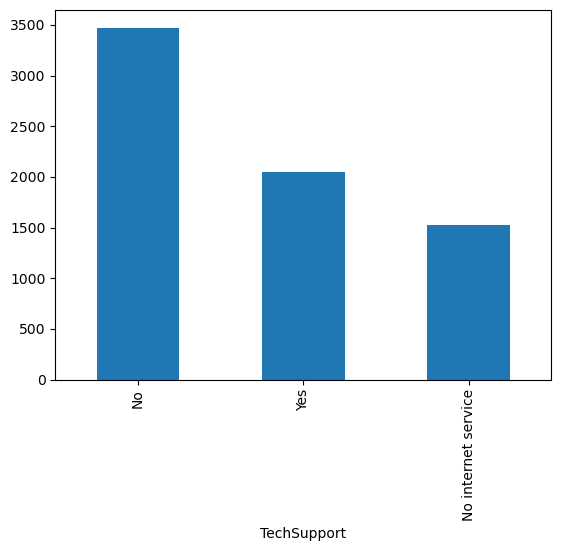

In [88]:
df['TechSupport'].value_counts().plot(kind='bar')

# `Bivariate Analysis`

## `Gender vs churn`

<Axes: xlabel='gender', ylabel='count'>

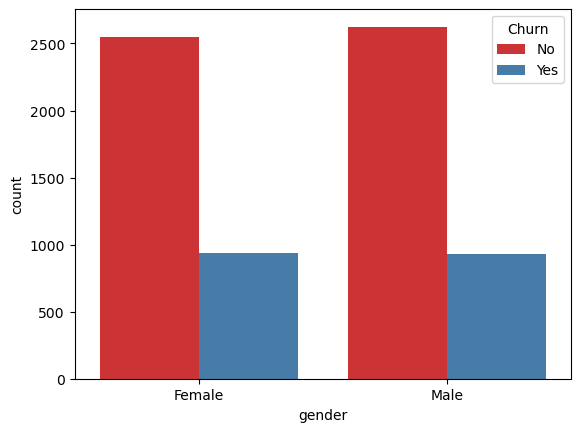

In [89]:
sns.countplot(data=df, x='gender', hue='Churn', palette='Set1')

## `Senior Citizen vs churn`

<Axes: xlabel='SeniorCitizen', ylabel='count'>

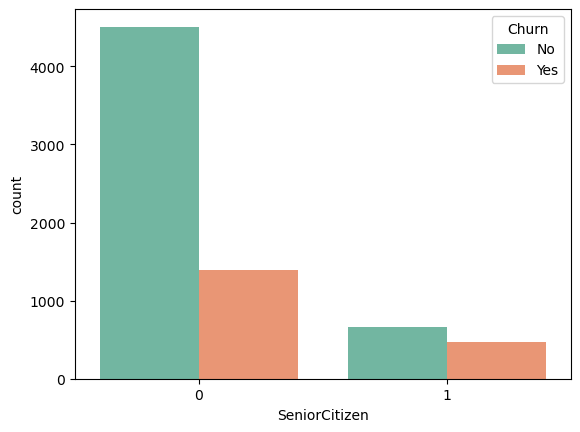

In [90]:
sns.countplot(data=df, x='SeniorCitizen', hue='Churn', palette='Set2')

## `Payment Method vs churn`

<Axes: xlabel='PaymentMethod', ylabel='count'>

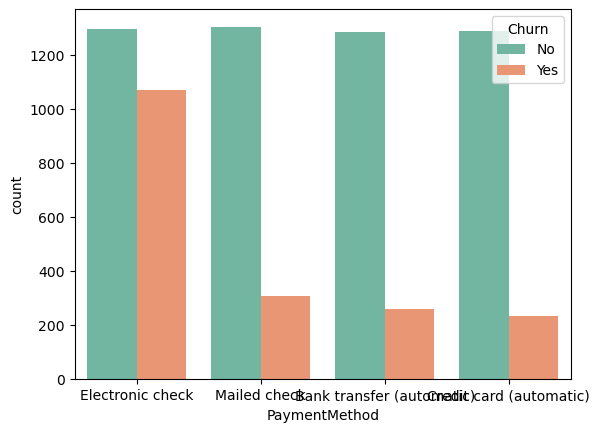

In [91]:
sns.countplot(data=df, x='PaymentMethod', hue='Churn', palette='Set2')

## `Contract type vs churn`

<Axes: xlabel='Contract', ylabel='count'>

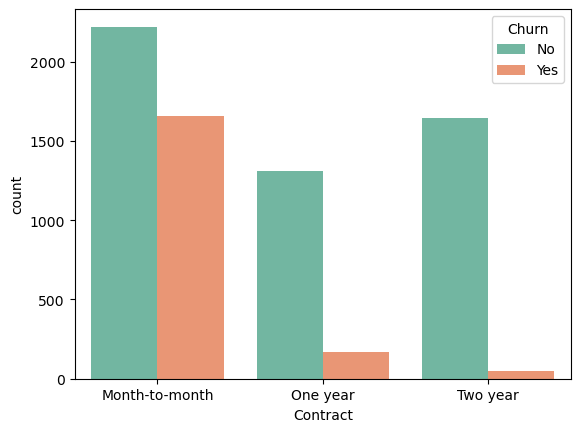

In [92]:
sns.countplot(data=df, x='Contract', hue='Churn', palette='Set2')

## `Dependents vs churn`

<Axes: xlabel='Dependents', ylabel='count'>

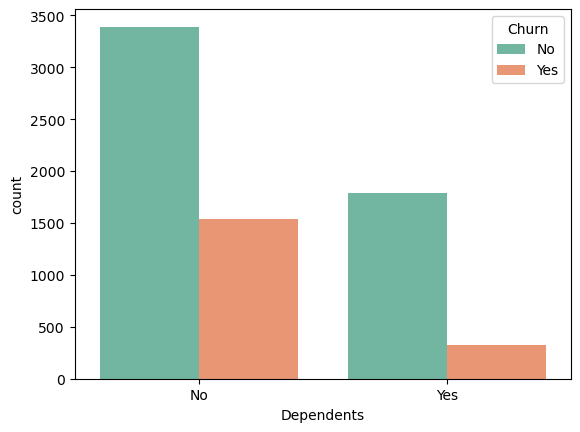

In [93]:
sns.countplot(data=df,x='Dependents', hue='Churn', palette='Set2')

## `Paper less billing vs churn`

<Axes: xlabel='PaperlessBilling', ylabel='count'>

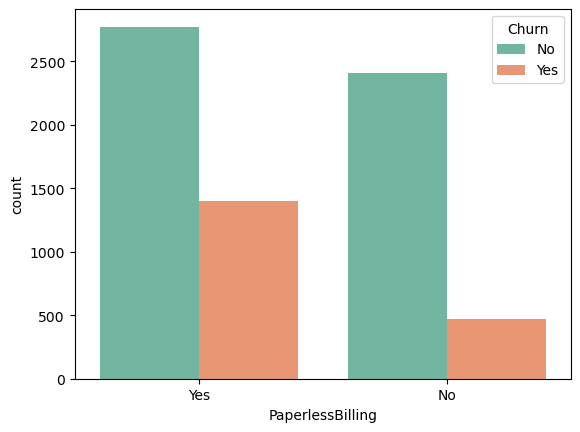

In [94]:
sns.countplot(data=df,x='PaperlessBilling', hue='Churn', palette='Set2')

In [95]:
df.groupby('PaperlessBilling')['Churn'].value_counts(normalize=True).unstack()

Churn,No,Yes
PaperlessBilling,,
No,0.836699,0.163301
Yes,0.664349,0.335651


In [96]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## `Streaming Movies vs churn`

<Axes: xlabel='StreamingMovies', ylabel='count'>

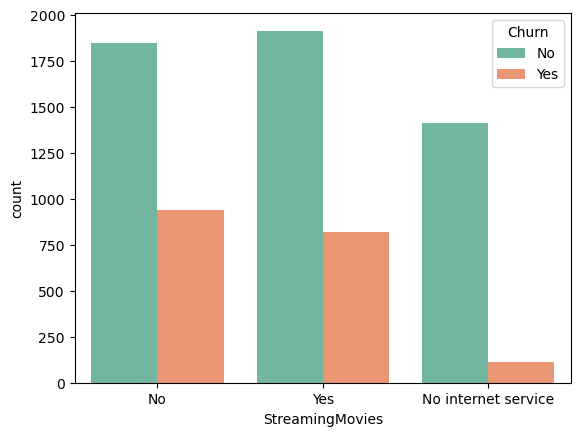

In [97]:
sns.countplot(data=df,x='StreamingMovies', hue='Churn', palette='Set2')

## `Tech Support billing vs churn`

<Axes: xlabel='TechSupport', ylabel='count'>

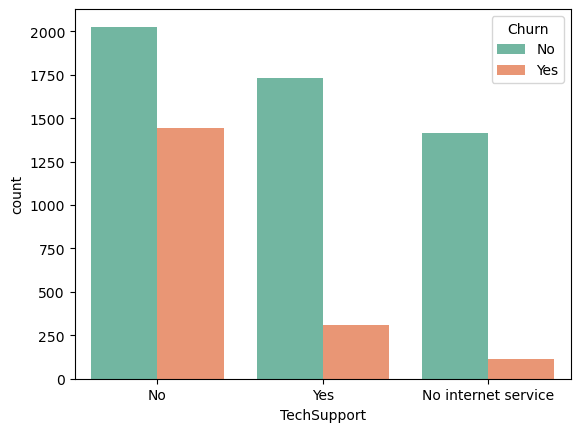

In [98]:
sns.countplot(data=df, x='TechSupport', hue='Churn', palette='Set2')

## `Device Protection vs churn`

<Axes: xlabel='DeviceProtection', ylabel='count'>

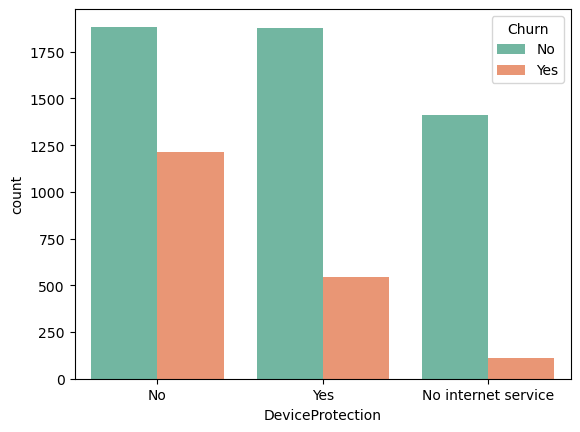

In [99]:
sns.countplot(data=df, x='DeviceProtection', hue='Churn', palette='Set2')

## `Online Security vs churn`

<Axes: xlabel='OnlineSecurity', ylabel='count'>

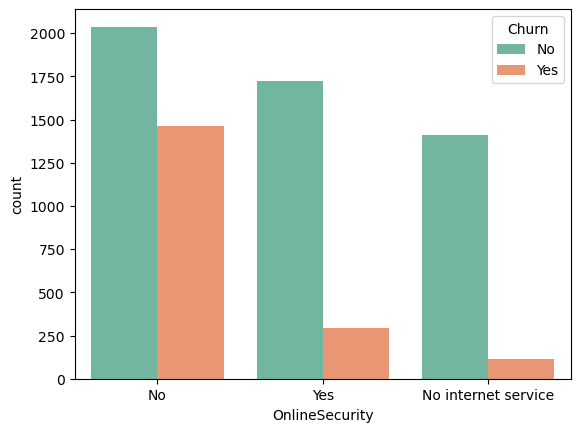

In [100]:
sns.countplot(data=df, x='OnlineSecurity', hue='Churn', palette='Set2')


## `Internet Services vs churn`

<Axes: xlabel='InternetService', ylabel='count'>

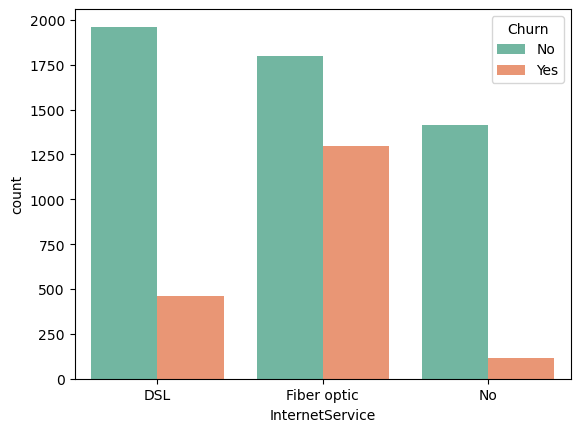

In [101]:
sns.countplot(data=df, x='InternetService', hue='Churn', palette='Set2')

## `Multiple Lines vs churn`

<Axes: xlabel='MultipleLines', ylabel='count'>

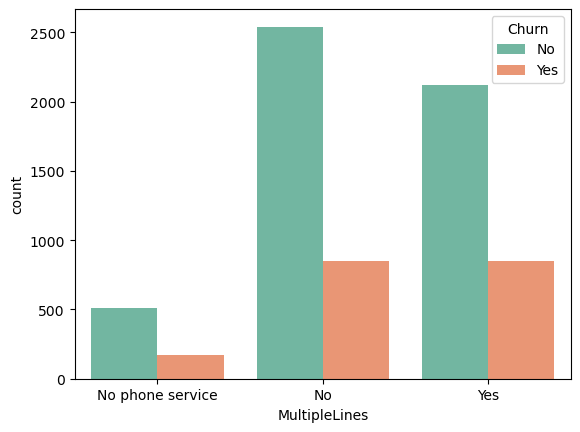

In [102]:
sns.countplot(data=df,x='MultipleLines', hue='Churn', palette='Set2')

## `Monthly Charges vs churn boxplot`

/var/folders/qx/720g_1z55gg_fwcvggbhs3_w0000gn/T/ipykernel_49484/67349780.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='MonthlyCharges', data=df, palette='Set2')


<Axes: xlabel='Churn', ylabel='MonthlyCharges'>

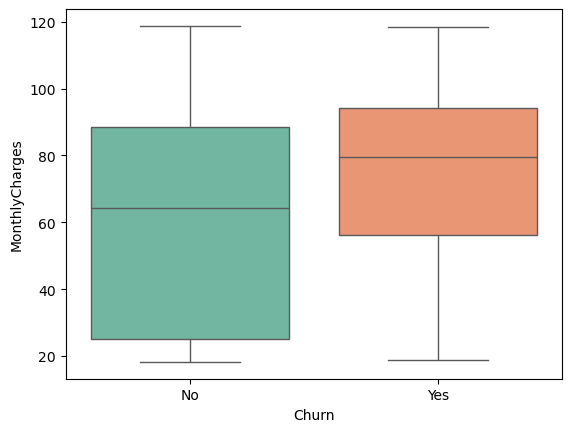

In [103]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=df, palette='Set2')

## `Tenure vs churn boxplot`

/var/folders/qx/720g_1z55gg_fwcvggbhs3_w0000gn/T/ipykernel_49484/1782891327.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='tenure', data=df, palette='Set2')


<Axes: xlabel='Churn', ylabel='tenure'>

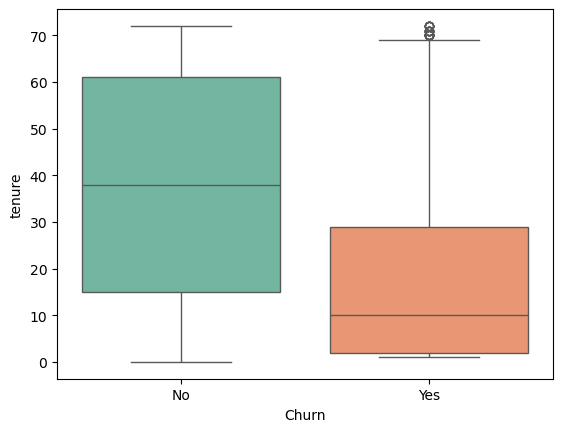

In [104]:
sns.boxplot(x='Churn', y='tenure', data=df, palette='Set2')

In [105]:
# Select only numerical columns
numerical_df = df.select_dtypes(include=['int64', 'float64'])
# Compute correlation matrix
corr_matrix = numerical_df.corr()

# Display correlation matrix
print(corr_matrix)


                tenure  MonthlyCharges
tenure          1.0000          0.2479
MonthlyCharges  0.2479          1.0000


In [106]:
df.dtypes

customerID            object
gender                object
SeniorCitizen       category
Partner               object
Dependents            object
tenure                 int64
PhoneService          object
MultipleLines         object
InternetService       object
OnlineSecurity        object
OnlineBackup          object
DeviceProtection      object
TechSupport           object
StreamingTV           object
StreamingMovies       object
Contract              object
PaperlessBilling      object
PaymentMethod         object
MonthlyCharges       float64
TotalCharges          object
Churn                 object
dtype: object

# `Modeling`

In [107]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

In [108]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## `Dropping customerID column`

In [109]:
df.drop(columns=['customerID'], inplace=True)

In [110]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [111]:
df = df.dropna(subset=['TotalCharges'])

In [112]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## `Splitting X and y`

In [113]:
X = df.drop(columns=['Churn'])
y = df['Churn']

In [114]:
df.sample(5)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
894,Female,0,Yes,No,63,Yes,Yes,Fiber optic,No,No,No,Yes,No,No,One year,Yes,Credit card (automatic),81.20,4965.10,No
4709,Female,1,No,No,56,Yes,Yes,Fiber optic,Yes,Yes,No,No,No,Yes,Month-to-month,Yes,Electronic check,96.85,5219.65,No
3328,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.25,70.25,No
4239,Male,0,Yes,Yes,56,No,No phone service,DSL,No,Yes,Yes,No,No,No,One year,Yes,Credit card (automatic),36.10,1971.50,No
2993,Male,0,Yes,Yes,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,20.40,20.40,No


## `Performing train test split`

In [115]:
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y,test_size=0.2, random_state=42)

In [116]:
len(X_train.dtypes)

19

## `Convert categorical columns to One Hot Encoded columns`


In [117]:
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()


In [118]:
numerical_cols


['tenure', 'MonthlyCharges', 'TotalCharges']

In [119]:
categorical_cols

['gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod']

In [120]:
onehot_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore',drop='first')

In [121]:
X_categorical = onehot_encoder.fit_transform(X_train[categorical_cols])

In [122]:
X_train_categorical_df = pd.DataFrame(X_categorical, columns=onehot_encoder.get_feature_names_out(categorical_cols),index=X_train.index)

In [123]:
X_train_categorical_df.sample(5)

,gender_Male,SeniorCitizen_1,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
5723,1.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3455,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
5358,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
5786,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0
2602,0.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,...,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0


In [124]:
X_test_categorical = onehot_encoder.transform(X_test[categorical_cols])

In [125]:
X_test_categorical_df = pd.DataFrame(X_test_categorical, columns=onehot_encoder.get_feature_names_out(categorical_cols),index=X_test.index)

In [126]:
X_test_categorical_df

,gender_Male,SeniorCitizen_1,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
974,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0
619,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4289,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
3721,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4533,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4829,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
5176,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
2750,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0
4432,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0


## `Perform standard scaling on numerical columns`

In [127]:
sc = StandardScaler()

In [128]:
X_train_numerical = sc.fit_transform(X_train[numerical_cols])

In [129]:
X_train_numerical_df = pd.DataFrame(X_train[numerical_cols], columns=numerical_cols, index=X_train.index)

In [130]:
X_train_numerical_df

,tenure,MonthlyCharges,TotalCharges
1413,65,94.55,6078.75
7003,26,35.75,1022.50
3355,68,90.20,6297.65
4494,3,84.30,235.05
3541,49,40.65,2070.75
...,...,...,...
3451,65,70.95,4555.20
5123,15,75.30,1147.45
4135,36,92.90,3379.25
4249,10,65.90,660.05


In [131]:
X_test_numerical = sc.transform(X_test[numerical_cols])

In [132]:
X_test_numerical_df = pd.DataFrame(X_test[numerical_cols], columns=numerical_cols, index=X_test.index)

In [133]:
X_train_trs = pd.concat([X_train_numerical_df, X_train_categorical_df], axis=1)
X_test_trs = pd.concat([X_test_numerical_df, X_test_categorical_df], axis=1)

# `Fitting Logistic Regression model`

In [134]:
lr = LogisticRegression()

In [135]:
lr.fit(X_train_trs, y_train)

/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [136]:
accuracy_score(y_test,lr.predict(X_test_trs))

0.7995735607675906

# `Classification report of  Logistic Regression model`

In [137]:
print(classification_report(y_test, lr.predict(X_test_trs)))

              precision    recall  f1-score   support

          No       0.85      0.88      0.87      1033
         Yes       0.64      0.57      0.60       374

    accuracy                           0.80      1407
   macro avg       0.74      0.73      0.73      1407
weighted avg       0.79      0.80      0.80      1407



# `Fitting Random Forest model`

In [138]:
from sklearn.ensemble import RandomForestClassifier

In [139]:
rf = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=15,class_weight='balanced', min_samples_leaf=5)
rf.fit(X_train_trs, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=15,
                       min_samples_leaf=5, random_state=42)

In [140]:
accuracy_score(y_test,rf.predict(X_test_trs))

0.7654584221748401

# `Classification report Random Forest model`

In [141]:
print(classification_report(y_test, rf.predict(X_test_trs)))

              precision    recall  f1-score   support

          No       0.90      0.77      0.83      1033
         Yes       0.54      0.75      0.63       374

    accuracy                           0.77      1407
   macro avg       0.72      0.76      0.73      1407
weighted avg       0.80      0.77      0.78      1407



In [142]:
importances = pd.DataFrame({
    'Feature': X_train_trs.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

# View top features
print(importances.head(10))

                               Feature  Importance
0                               tenure    0.186775
2                         TotalCharges    0.148019
1                       MonthlyCharges    0.103368
25                   Contract_Two year    0.097736
10         InternetService_Fiber optic    0.072085
28      PaymentMethod_Electronic check    0.055765
24                   Contract_One year    0.038765
13                  OnlineSecurity_Yes    0.028560
19                     TechSupport_Yes    0.022820
12  OnlineSecurity_No internet service    0.021284


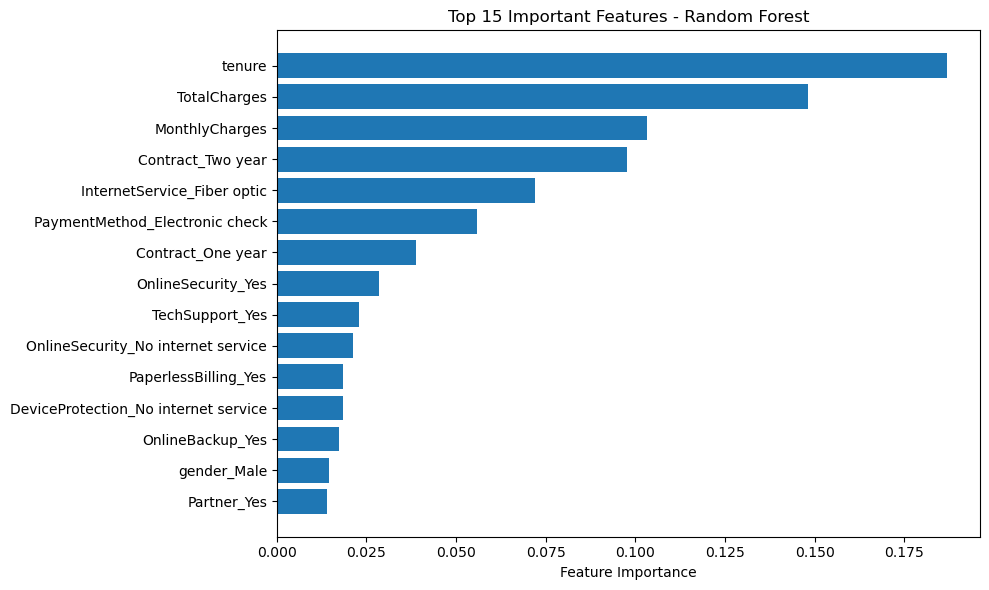

In [143]:
plt.figure(figsize=(10, 6))
plt.barh(importances.head(15)['Feature'][::-1], importances.head(15)['Importance'][::-1])
plt.title("Top 15 Important Features - Random Forest")
plt.xlabel("Feature Importance")
plt.tight_layout()
plt.show()


In [144]:
y_train = y_train.map({'No': 0, 'Yes': 1})
y_test = y_test.map({'No': 0, 'Yes': 1})
y_train.value_counts()
y_test.value_counts()

Churn
0    1033
1     374
Name: count, dtype: int64

# `Fitting XGBClassifier model`

In [145]:
from xgboost import XGBClassifier
xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.01,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=2.8,  # handles imbalance
    use_label_encoder=True,
    eval_metric='logloss',
    random_state=42
)


In [146]:
xgb_model.fit(X_train_trs, y_train)

/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [00:54:28] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.01, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

# `Classification report of XGBClassifier model`

In [147]:
print(classification_report(y_test, xgb_model.predict(X_test_trs)))

              precision    recall  f1-score   support

           0       0.91      0.72      0.80      1033
           1       0.51      0.80      0.62       374

    accuracy                           0.74      1407
   macro avg       0.71      0.76      0.71      1407
weighted avg       0.80      0.74      0.76      1407



# `Modeling with a voting ensemble`

In [148]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression

# Base models
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced',
    random_state=42
)

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    scale_pos_weight=3.0,  # Adjust depending on class imbalance
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

gb = GradientBoostingClassifier(
    n_estimators=150,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)

# Voting ensemble (soft voting preferred)
ensemble = VotingClassifier(
    estimators=[
        ('rf', rf),
        ('xgb', xgb),
        ('gb', gb)
    ],
    voting='soft',  # use probabilities for better class balance
    weights=[1, 10, 1]  # xgb gets higher weight
)
ensemble.fit(X_train_trs, y_train)

/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [00:54:31] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


VotingClassifier(estimators=[('rf',
                              RandomForestClassifier(class_weight='balanced',
                                                     max_depth=10,
                                                     n_estimators=200,
                                                     random_state=42)),
                             ('xgb',
                              XGBClassifier(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=None, device=None,
                                            early_stopping_rounds=None,
                                            enable_categorical=False,
                                            eval_metric='logloss',
                                            fe...
                                            learning_rate=0.1, max_bin=None,
                                            max_cat_threshold=None,
                                            max_cat_to_onehot=None,
                                            max_delta_step=None, max_depth=5,
                                            max_leaves=None,
                                            min_child_weight=None, missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=200, n_jobs=None,
                                            num_parallel_tree=None, ...)),
                             ('gb',
                              GradientBoostingClassifier(max_depth=5,
                                                         n_estimators=150,
                                                         random_state=42))],
                 voting='soft', weights=[1, 10, 1])

# `Classification report of Voting Ensemble`

In [149]:
print(classification_report(y_test, ensemble.predict(X_test_trs)))

              precision    recall  f1-score   support

           0       0.89      0.75      0.81      1033
           1       0.52      0.75      0.61       374

    accuracy                           0.75      1407
   macro avg       0.71      0.75      0.71      1407
weighted avg       0.79      0.75      0.76      1407



# `Stacking Ensemble model`

In [150]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

# Base models
base_estimators = [
    ('rf', RandomForestClassifier(class_weight='balanced', max_depth=10, random_state=42)),
    ('xgb', XGBClassifier(use_label_encoder=False, eval_metric='logloss', scale_pos_weight=3.0, random_state=42)),
    ('gb', GradientBoostingClassifier(random_state=42))
]

# Meta-model (can also be XGBoost or LogisticRegression)
meta_model = LogisticRegression(class_weight='balanced', max_iter=2000)

# Stacking classifier
stack = StackingClassifier(
    estimators=base_estimators,
    final_estimator=meta_model,
    cv=5,
    passthrough=False,
    n_jobs=-1
)
stack.fit(X_train_trs, y_train)

/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [00:54:36] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
[00:54:37] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

[00:54:37] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

[00:54:37] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

[00:54:37] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

[00:54:37] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.



StackingClassifier(cv=5,
                   estimators=[('rf',
                                RandomForestClassifier(class_weight='balanced',
                                                       max_depth=10,
                                                       random_state=42)),
                               ('xgb',
                                XGBClassifier(base_score=None, booster=None,
                                              callbacks=None,
                                              colsample_bylevel=None,
                                              colsample_bynode=None,
                                              colsample_bytree=None,
                                              device=None,
                                              early_stopping_rounds=None,
                                              enable_categorical=False,
                                              eval_metric='logloss',
                                              feature_type...
                                              max_cat_threshold=None,
                                              max_cat_to_onehot=None,
                                              max_delta_step=None,
                                              max_depth=None, max_leaves=None,
                                              min_child_weight=None,
                                              missing=nan,
                                              monotone_constraints=None,
                                              multi_strategy=None,
                                              n_estimators=None, n_jobs=None,
                                              num_parallel_tree=None, ...)),
                               ('gb',
                                GradientBoostingClassifier(random_state=42))],
                   final_estimator=LogisticRegression(class_weight='balanced',
                                                      max_iter=2000),
                   n_jobs=-1)

# `Classification report of Stacking Ensemble`

In [151]:
print(classification_report(y_test, stack.predict(X_test_trs)))

              precision    recall  f1-score   support

           0       0.90      0.74      0.81      1033
           1       0.52      0.78      0.62       374

    accuracy                           0.75      1407
   macro avg       0.71      0.76      0.72      1407
weighted avg       0.80      0.75      0.76      1407



## `Project Goal`

The goal of this project is to build a machine learning model that can accurately **predict customer churn** for a telecom company. By identifying customers who are likely to leave, the company can take proactive measures to retain them, reduce churn-related revenue loss, and improve customer satisfaction.

---

##  `Conclusion`

We evaluated multiple machine learning models for predicting customer churn using the Telco dataset. Each model was assessed using precision, recall, F1-score, and overall accuracy. Here's a summary of the findings:

---

### `Key Observations:`

| Model                   | Churn Recall | Churn Precision | Churn F1-score | Accuracy |
|------------------------|---------------|------------------|----------------|----------|
| **Logistic Regression** | 0.57          | 0.64             | 0.60           | **0.80**  |
| **Random Forest**       | 0.75        | 0.54             | 0.63           | 0.77     |
| **XGBoost**             | 0.80         | 0.51             | 0.62           | 0.74     |
| **Voting Ensemble**     | 0.75         | 0.52             | 0.61           | 0.75     |
| **Stacking Ensemble**   | 0.78         | 0.52             | 0.62           | 0.75     |

---


### `Insights:`

- **Logistic Regression** achieved the highest **accuracy (80%)**, but had **lower recall (0.57)** on churners, which may limit its effectiveness in proactive retention.
- **XGBoost** and **Stacking Ensemble** delivered the **highest recall (0.80 and 0.78)**, meaning they are **better at identifying customers who churn**, which is crucial for churn prevention.
- **Ensemble methods** (Voting and Stacking) achieved a good balance between recall and F1-score, making them **robust candidates**.
- **Random Forest** offers a middle ground, with reasonable precision and high recall.

---

### `Final Recommendation:`

If the business objective prioritizes **identifying as many churners as possible (high recall)** to take retention action, then:

- **XGBoost** or **Stacking Ensemble (meta: Logistic Regression)** would be the best choices.

If **interpretability and deployment simplicity** are more important:

- **Logistic Regression** is still a strong baseline due to its high accuracy and explainability.

---

## `Key Insights from Exploratory Data Analysis`

### 1. Gender vs Churn
- Churn rates for **male and female** customers are nearly identical.
- **Gender is not a significant predictor** of churn.

### 2. Senior Citizen vs Churn
- **Senior citizens** have a higher churn rate compared to younger customers.
- This demographic may need targeted retention strategies.

### 3. Payment Method vs Churn
- Customers who pay via **Electronic Check** churn more than those using **Mailed Check, Bank Transfer, or Credit Card (automatic)**.
- **Electronic payment users** may feel less locked-in and more price-sensitive.

### 4. Contract Type vs Churn
- **Month-to-month contracts** have the highest churn rate.
- **One-year and two-year contract customers** churn significantly less, showing that longer contracts are associated with retention.

### 5. Dependents vs Churn
- Customers with **dependents churn less** than those without.
- Suggests that customers with families may be more stable or loyal.

### 6. Paperless Billing vs Churn
- Customers who opted for **paperless billing** have higher churn rates.
- May correlate with digital engagement or dissatisfaction with communication methods.

### 7. Tech Support vs Churn
- Customers **with tech support churn less**.
- Those **without** tech support show high churn, highlighting the importance of support services in retention.

### 8. Device Protection vs Churn
- **Churn is higher among customers without device protection**.
- Device-related add-ons may play a role in retaining users.

### 9. Online Security vs Churn
- Customers with **online security** are less likely to churn.
- Suggests that value-added services improve retention.

### 10. Monthly Charges vs Churn
- Customers who churn generally have **higher monthly charges**.
- Price sensitivity is a key factor in churn — customers with lower charges are more likely to stay.

### 11. Tenure vs Churn
- Customers who **churned** tend to have **much shorter tenure** with the company.
- The median tenure for churned customers is around **10 months**, while for non-churned customers it's nearly **40 months**.
- This suggests that **newer customers are more likely to churn**, reinforcing the importance of early engagement and onboarding strategies.

---